In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip "/content/drive/MyDrive/SkinDiseaseProject/skin-disease-dermnet.zip" -d /content/data

unzip:  cannot find or open /content/drive/MyDrive/SkinDiseaseProject/skin-disease-dermnet.zip, /content/drive/MyDrive/SkinDiseaseProject/skin-disease-dermnet.zip.zip or /content/drive/MyDrive/SkinDiseaseProject/skin-disease-dermnet.zip.ZIP.


In [4]:
!ls /content/drive/MyDrive/

'Colab Notebooks'   skin-disease-dermnet.zip


In [5]:
!unzip "/content/drive/MyDrive/skin-disease-dermnet.zip" -d /content/data

Archive:  /content/drive/MyDrive/skin-disease-dermnet.zip
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (193).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (194).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (195).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (196).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (197).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (198).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (199).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (200).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (201).jpg  
  inflating: /content/data/Penyakit Kulit/test/Acne and Rosacea/Acne and Rosacea_ (202).jpg  
  

In [6]:
## Check Folder Structure
import os

print(os.listdir('/content/data'))
print(os.listdir('/content/data/Penyakit Kulit'))

['Penyakit Kulit']
['train', 'test']


In [7]:
## Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
## Define Image Settings
img_size = (224, 224)
batch_size = 32

In [9]:
## Create Data Generators
train_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

In [10]:
##Load Training Data
train_data = train_datagen.flow_from_directory(
    '/content/data/Penyakit Kulit/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 4416 images belonging to 23 classes.


In [11]:
## Load Testing Data
test_data = test_datagen.flow_from_directory(
    '/content/data/Penyakit Kulit/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 460 images belonging to 23 classes.


In [12]:
print("Classes:", train_data.class_indices)
print("Number of training images:", train_data.samples)
print("Number of testing images:", test_data.samples)

Classes: {'Acne and Rosacea': 0, 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions': 1, 'Atopic Dermatitis': 2, 'Bullous Disease': 3, 'Cellulitis Impetigo and other Bacterial Infections': 4, 'Eczema': 5, 'Exanthems and Drug Eruptions': 6, 'Hair Loss Photos Alopecia and other Hair Diseases': 7, 'Herpes HPV and other STDs': 8, 'Light Diseases and Disorders of Pigmentation': 9, 'Lupus and other Connective Tissue Diseases': 10, 'Melanoma Skin Cancer Nevi and Moles': 11, 'Nail Fungus and other Nail Disease': 12, 'Poison Ivy Photos and other Contact Dermatitis': 13, 'Psoriasis pictures Lichen Planus and Related Diseases': 14, 'Scabies Lyme Disease and other Infestations and Bites': 15, 'Seborrheic Keratoses and other Benign Tumors': 16, 'Systemic Disease': 17, 'Tinea Ringworm Candidiasis and other Fungal Infections': 18, 'Urticaria Hives': 19, 'Vascular Tumors': 20, 'Vasculitis Photos': 21, 'Warts Molluscum and other Viral Infections': 22}
Number of training images: 4416
Nu

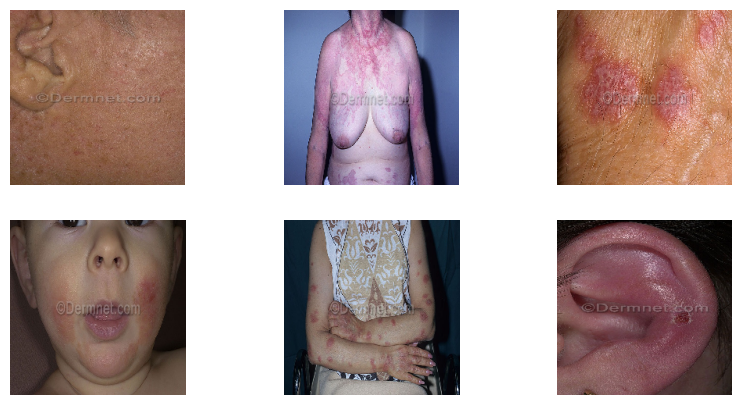

In [13]:
## Display Sample Images
images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

Build CNN model

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [15]:
cnn_model = Sequential()

cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(train_data.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,171,927 (42.62 MB)

 Trainable params: 11,171,927 (42.62 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
cnn_history = cnn_model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 31s 166ms/step - accuracy: 0.0539 - loss: 3.1571 - val_accuracy: 0.0500 - val_loss: 3.1149
Epoch 2/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.0713 - loss: 3.0917 - val_accuracy: 0.1043 - val_loss: 3.0966
Epoch 3/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - accuracy: 0.1035 - loss: 3.0132 - val_accuracy: 0.1065 - val_loss: 3.0637
Epoch 4/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 140ms/step - accuracy: 0.1585 - loss: 2.8597 - val_accuracy: 0.1261 - val_loss: 3.0901
Epoch 5/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - accuracy: 0.2253 - loss: 2.6226 - val_accuracy: 0.1217 - val_loss: 3.1610


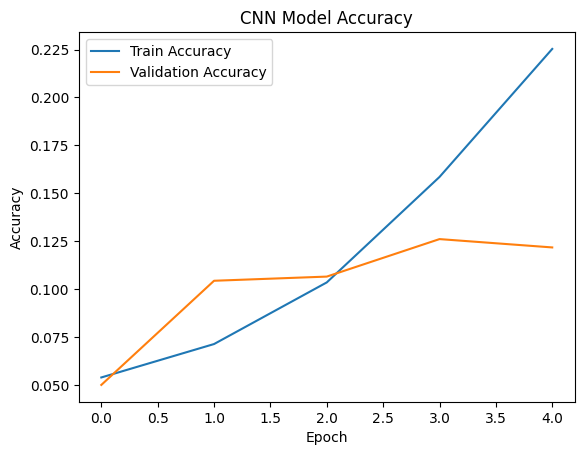

In [19]:
plt.plot(cnn_history.history['accuracy'])
plt.plot(cnn_history.history['val_accuracy'])

plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train Accuracy', 'Validation Accuracy'])

plt.show()

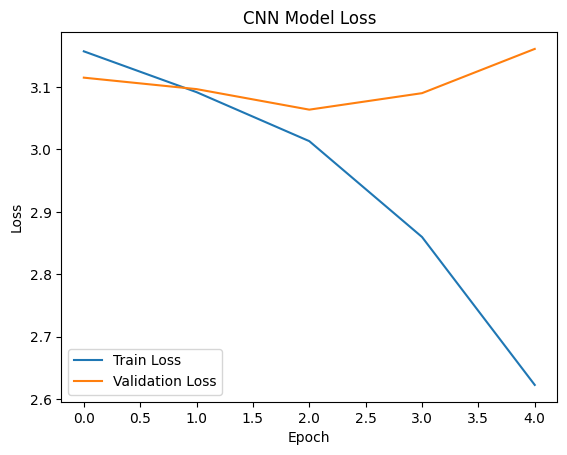

In [20]:
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])

plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])

plt.show()

In [21]:
test_loss, test_accuracy = cnn_model.evaluate(test_data)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.1217 - loss: 3.1610
Test Accuracy: 0.12173912674188614
Test Loss: 3.160950183868408


In [22]:
cnn_model.save('/content/cnn_model.h5')

In [23]:
from google.colab import files

files.download('/content/cnn_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>